# 16. Fraud Decision Logic


## 1. Decision Logic Objective

Threshold tuning in notebook `15_threshold_tuning.ipynb` selected probability cutoffs for routing transactions into business actions. This notebook does not retrain models, retune thresholds, or reselect the best model. It only converts the final Random Forest fraud probability into an operational decision.

The goal is to create an API-ready decision layer for fraud detection:

- `APPROVE` for low-risk transactions
- `REVIEW` for medium-risk transactions requiring manual or secondary review
- `BLOCK` for high-risk transactions that meet the high-confidence fraud threshold

This notebook continues the project path from model training, model evaluation, and threshold tuning toward a FastAPI `/predict` response. Later notebooks or application code can combine this decision system with complaint sentiment and summarization features.


## 2. Load Libraries and Project Paths

This section imports the libraries used for decision logic, tabular summaries, and figures. It also defines project-relative paths and creates the output folders for notebook 16. Using `Path` keeps the notebook portable and avoids hardcoded absolute paths.


In [21]:
import json
import os
import sys
from pathlib import Path
from typing import Any

# Keep Matplotlib cache inside the project workspace so notebook execution works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    Image = None
    Markdown = str
    display = print

sys.path.append(str(Path(".." ).resolve()))
try:
    from src.config import PROJECT_ROOT
except ImportError:
    PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
DECISION_TABLES_DIR = REPORTS_TABLES_DIR / "16_decision_logic"
DECISION_FIGURES_DIR = REPORTS_FIGURES_DIR / "16_decision_logic"

THRESHOLD_ARTIFACT_FILE = ARTIFACTS_DIR / "selected_threshold.json"
PREDICTION_FILE = REPORTS_TABLES_DIR / "13_model_training" / "baseline_test_predictions.csv"
DECISION_POLICY_FILE = ARTIFACTS_DIR / "decision_policy.json"

DECISION_THRESHOLD_SUMMARY_FILE = DECISION_TABLES_DIR / "decision_threshold_summary.csv"
HOLDOUT_DECISION_RESULTS_FILE = DECISION_TABLES_DIR / "holdout_decision_results.csv"
BUSINESS_IMPACT_FILE = DECISION_TABLES_DIR / "business_impact_by_decision.csv"
FRAUD_CAPTURE_SUMMARY_FILE = DECISION_TABLES_DIR / "fraud_capture_summary.csv"
ERROR_ANALYSIS_FILE = DECISION_TABLES_DIR / "error_analysis_by_decision.csv"
POLICY_COMPARISON_FILE = DECISION_TABLES_DIR / "decision_policy_comparison.csv"
FINAL_DECISION_SUMMARY_FILE = DECISION_TABLES_DIR / "final_decision_summary.csv"

TRANSACTION_VOLUME_FIGURE = DECISION_FIGURES_DIR / "transaction_volume_by_decision.png"
ACTUAL_FRAUDS_FIGURE = DECISION_FIGURES_DIR / "actual_frauds_by_decision.png"
PROBABILITY_DISTRIBUTION_FIGURE = DECISION_FIGURES_DIR / "fraud_probability_by_decision.png"
FRAUD_VS_LEGITIMATE_FIGURE = DECISION_FIGURES_DIR / "fraud_vs_legitimate_by_decision.png"

DECISION_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DECISION_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Threshold artifact: {THRESHOLD_ARTIFACT_FILE}")
print(f"Holdout prediction file: {PREDICTION_FILE}")
print(f"Decision tables directory: {DECISION_TABLES_DIR}")
print(f"Decision figures directory: {DECISION_FIGURES_DIR}")


Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
Threshold artifact: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json
Holdout prediction file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/baseline_test_predictions.csv
Decision tables directory: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/16_decision_logic
Decision figures directory: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/16_decision_logic


## 3. Load Threshold Artifact from Notebook 15

Notebook 15 saved the final threshold configuration after validation/OOF threshold selection and holdout confirmation. This notebook consumes that artifact instead of hardcoding thresholds or selecting new ones.

The loaded configuration should identify the selected model, the review threshold, the operational block threshold, and any optional block threshold candidate kept for comparison.


In [22]:
if not THRESHOLD_ARTIFACT_FILE.exists():
    raise FileNotFoundError(f"Missing threshold artifact from notebook 15: {THRESHOLD_ARTIFACT_FILE}")

threshold_config = json.loads(THRESHOLD_ARTIFACT_FILE.read_text(encoding="utf-8"))

model_name = threshold_config.get("model_name")
review_threshold = threshold_config.get("review_threshold")
block_threshold = threshold_config.get("block_threshold")
block_threshold_candidate = threshold_config.get("block_threshold_candidate")
threshold_selection_source = threshold_config.get("threshold_selection_source")

loaded_threshold_config = pd.DataFrame(
    [
        {"setting": "model_name", "value": model_name},
        {"setting": "review_threshold", "value": review_threshold},
        {"setting": "block_threshold", "value": block_threshold},
        {"setting": "block_threshold_candidate", "value": block_threshold_candidate},
        {"setting": "threshold_selection_source", "value": threshold_selection_source},
    ]
)

display(loaded_threshold_config)


,setting,value
0,model_name,Random Forest
1,review_threshold,0.350000
2,block_threshold,0.500000
3,block_threshold_candidate,0.821000
4,threshold_selection_source,validation_or_oof


### Loaded Threshold Artifact Interpretation

This table confirms the notebook is using the saved threshold policy from notebook 15. The Random Forest probability remains the selected fraud score, `review_threshold` starts the manual review zone, and `block_threshold` is the operational high-confidence fraud threshold. The optional `block_threshold_candidate` is retained for comparison only unless the artifact explicitly saves it as the operational block threshold.


## 4. Validate Threshold Configuration

Before applying business decisions, the threshold configuration must be valid. The review and block thresholds must exist, must be probabilities between 0 and 1, and the block threshold must be greater than the review threshold. These checks prevent downstream API code from using an unsafe decision policy.


In [23]:
def validate_probability_threshold(value: Any, threshold_name: str) -> float:
    """Validate one probability threshold and return it as a float."""
    if value is None:
        raise ValueError(f"{threshold_name} is missing from {THRESHOLD_ARTIFACT_FILE}")

    threshold = float(value)
    if not 0 <= threshold <= 1:
        raise ValueError(f"{threshold_name} must be between 0 and 1. Got {threshold}.")
    return threshold


review_threshold = validate_probability_threshold(review_threshold, "review_threshold")
block_threshold = validate_probability_threshold(block_threshold, "block_threshold")

if block_threshold <= review_threshold:
    raise ValueError(
        "block_threshold must be greater than review_threshold. "
        f"Got review_threshold={review_threshold:.3f}, block_threshold={block_threshold:.3f}."
    )

if block_threshold_candidate is not None:
    block_threshold_candidate = validate_probability_threshold(block_threshold_candidate, "block_threshold_candidate")

print("Threshold configuration is valid.")
print(f"review_threshold = {review_threshold:.3f}")
print(f"block_threshold = {block_threshold:.3f}")
print(f"block_threshold_candidate = {block_threshold_candidate if block_threshold_candidate is not None else 'not available'}")


Threshold configuration is valid.
review_threshold = 0.350
block_threshold = 0.500
block_threshold_candidate = 0.821


## 5. Explain Selected Thresholds

This table translates the saved threshold values into business language. It is saved as a reusable documentation table for reporting and API integration work.


In [24]:
threshold_summary_rows = [
    {
        "threshold_name": "review_threshold",
        "value": review_threshold,
        "decision_boundary": "review_threshold <= fraud_probability < block_threshold",
        "business_meaning": "Starts the manual review zone for medium-risk transactions.",
    },
    {
        "threshold_name": "block_threshold",
        "value": block_threshold,
        "decision_boundary": "fraud_probability >= block_threshold",
        "business_meaning": "Starts the automatic block zone for high-confidence fraud risk.",
    },
    {
        "threshold_name": "block_threshold_candidate",
        "value": block_threshold_candidate,
        "decision_boundary": "Optional stricter block comparison only",
        "business_meaning": "Preserved from threshold tuning for business comparison; not used as the default final policy unless saved as block_threshold.",
    },
]

threshold_summary = pd.DataFrame(threshold_summary_rows)
threshold_summary.to_csv(DECISION_THRESHOLD_SUMMARY_FILE, index=False)

display(threshold_summary)
print(f"Saved threshold summary to: {DECISION_THRESHOLD_SUMMARY_FILE}")


,threshold_name,value,decision_boundary,business_meaning
0,review_threshold,0.350000,review_threshold <= fraud_probability < block_...,Starts the manual review zone for medium-risk ...
1,block_threshold,0.500000,fraud_probability >= block_threshold,Starts the automatic block zone for high-confi...
2,block_threshold_candidate,0.821000,Optional stricter block comparison only,Preserved from threshold tuning for business c...


Saved threshold summary to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/16_decision_logic/decision_threshold_summary.csv


### Threshold Summary Interpretation

The `review_threshold` starts the manual review zone. Transactions at or above this value are suspicious enough for additional checks, but not necessarily high-confidence fraud.

The `block_threshold` starts the automatic block zone. Transactions at or above this value are treated as high-risk enough for a `BLOCK` decision under the final operational policy.

The `block_threshold_candidate` is shown for transparency and business discussion only. It is not used as the default block threshold unless it is explicitly saved as `block_threshold` in the threshold artifact.


## 6. Load Holdout/Test Predictions

This notebook evaluates decision logic on the saved holdout/test predictions from notebook 13. The Random Forest probability is used because Random Forest was selected as the final model in the earlier evaluation workflow.

The notebook requires `y_true` for evaluation and `random_forest_probability` for decisions. If `transaction_id` is missing, the notebook creates one from the row index so every decision can still be traced.


In [25]:
if not PREDICTION_FILE.exists():
    raise FileNotFoundError(f"Missing holdout/test prediction file: {PREDICTION_FILE}")

predictions = pd.read_csv(PREDICTION_FILE)

required_prediction_columns = {"y_true", "random_forest_probability"}
missing_prediction_columns = sorted(required_prediction_columns - set(predictions.columns))
if missing_prediction_columns:
    raise ValueError(
        "Holdout/test prediction file is missing required columns "
        f"{missing_prediction_columns}. Random Forest probability is required and no fallback model is used."
    )

if "transaction_id" not in predictions.columns:
    predictions = predictions.reset_index().rename(columns={"index": "transaction_id"})
    print("transaction_id was missing, so it was created from the prediction row index.")
else:
    print("transaction_id column found in prediction file.")

predictions = predictions.copy()
predictions["y_true"] = predictions["y_true"].astype(int)
predictions["random_forest_probability"] = predictions["random_forest_probability"].astype(float)

prediction_overview = pd.DataFrame(
    [
        {"metric": "Rows", "value": len(predictions)},
        {"metric": "Actual frauds", "value": int(predictions["y_true"].sum())},
        {"metric": "Actual legitimate", "value": int((predictions["y_true"] == 0).sum())},
        {"metric": "Minimum Random Forest probability", "value": float(predictions["random_forest_probability"].min())},
        {"metric": "Maximum Random Forest probability", "value": float(predictions["random_forest_probability"].max())},
    ]
)

display(prediction_overview)
display(predictions[["transaction_id", "y_true", "random_forest_probability"]].head())


transaction_id column found in prediction file.


,metric,value
0,Rows,56746.000000
1,Actual frauds,95.000000
2,Actual legitimate,56651.000000
3,Minimum Random Forest probability,0.000000
4,Maximum Random Forest probability,1.000000


,transaction_id,y_true,random_forest_probability
0,5,0,0.000000
1,9,0,0.000000
2,10,0,0.000000
3,13,0,0.000000
4,15,0,0.000000


### Holdout Prediction Interpretation

The overview confirms the number of holdout/test transactions, the number of actual fraud cases, and the range of Random Forest probabilities. These probabilities are the only model scores used by the decision policy in this notebook.


## 7. Define Decision Logic Function

The decision function converts one fraud probability into one business action. The function follows the final policy from notebook 15: block at or above the block threshold, review between the review and block thresholds, and approve below the review threshold.


In [26]:
def assign_fraud_decision(fraud_probability: float, review_threshold: float, block_threshold: float) -> str:
    """Convert a fraud probability into APPROVE, REVIEW, or BLOCK."""
    if fraud_probability >= block_threshold:
        return "BLOCK"
    if fraud_probability >= review_threshold:
        return "REVIEW"
    return "APPROVE"


## 8. Define Decision Reason Function

A production API should return not only a decision, but also a short reason that explains why the decision was made. The reason text below is intentionally simple and business-readable.


In [27]:
def generate_decision_reason(
    fraud_probability: float,
    decision: str,
    review_threshold: float,
    block_threshold: float,
) -> str:
    """Create a human-readable explanation for a fraud decision."""
    probability_text = f"fraud probability {fraud_probability:.3f}"
    if decision == "BLOCK":
        return (
            f"{probability_text} is greater than or equal to the block threshold "
            f"{block_threshold:.3f}; high risk transaction should be blocked."
        )
    if decision == "REVIEW":
        return (
            f"{probability_text} is between the review threshold {review_threshold:.3f} "
            f"and block threshold {block_threshold:.3f}; medium risk transaction needs manual review."
        )
    if decision == "APPROVE":
        return (
            f"{probability_text} is below the review threshold {review_threshold:.3f}; "
            "low risk transaction can be approved."
        )
    raise ValueError(f"Unknown decision: {decision}")


## 9. Define Risk Level Function

Risk levels provide a more descriptive label than the three operational decisions. They are useful for dashboards, API responses, and analyst triage. The medium-risk boundary uses the saved review threshold.


In [ ]:
def assign_risk_level(
    fraud_probability: float,
    review_threshold: float,
    block_threshold: float,
) -> str:
    """Assign a descriptive risk level from a fraud probability."""
    high_risk_boundary = max(block_threshold - 0.10, review_threshold)
    if fraud_probability >= block_threshold:
        return "Very High Risk"
    if fraud_probability >= high_risk_boundary:
        return "High Risk"
    if fraud_probability >= review_threshold:
        return "Medium Risk"
    if fraud_probability >= 0.10:
        return "Low-Medium Risk"
    return "Low Risk"


## 10. Apply Decision Logic to Holdout/Test Predictions

This section creates the transaction-level decision table. It keeps the original holdout/test prediction rows, adds the Random Forest fraud probability under a generic `fraud_probability` name, and then assigns the decision, risk level, and decision reason.

This table is the closest notebook output to what a future FastAPI `/predict` endpoint will return for each transaction.


In [ ]:
decision_results = predictions.copy()
decision_results["fraud_probability"] = decision_results["random_forest_probability"]
decision_results["decision"] = decision_results["fraud_probability"].apply(
    lambda probability: assign_fraud_decision(probability, review_threshold, block_threshold)
)
decision_results["risk_level"] = decision_results["fraud_probability"].apply(
    lambda probability: assign_risk_level(probability, review_threshold, block_threshold)
)
decision_results["decision_reason"] = decision_results.apply(
    lambda row: generate_decision_reason(
        row["fraud_probability"],
        row["decision"],
        review_threshold,
        block_threshold,
    ),
    axis=1,
)

sample_decision_output = decision_results[
    ["transaction_id", "y_true", "fraud_probability", "risk_level", "decision", "decision_reason"]
].head(10)

decision_results.to_csv(HOLDOUT_DECISION_RESULTS_FILE, index=False)

display(sample_decision_output)
print(f"Saved holdout decision results to: {HOLDOUT_DECISION_RESULTS_FILE}")


### Holdout Decision Results Interpretation

Each row shows how a transaction moves from fraud probability to a business action. `APPROVE` means the score is below the review threshold, `REVIEW` means it falls in the manual review band, and `BLOCK` means it meets or exceeds the operational block threshold. The decision reason is designed to be understandable in API logs or analyst tools.


## 11. Business Impact by Decision

The grouped business-impact table summarizes how many transactions fall into each decision group and how many actual fraud cases appear in each group. This is important because fraud models are not only classification models; they create operational workload and customer-impact decisions.


In [ ]:
DECISION_ORDER = ["BLOCK", "REVIEW", "APPROVE"]

def summarize_business_impact(decision_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize transaction volume and fraud rate by decision."""
    grouped = (
        decision_df.assign(
            decision=pd.Categorical(decision_df["decision"], categories=DECISION_ORDER, ordered=True)
        ).groupby("decision", observed=False)
        .agg(
            total_transactions=("transaction_id", "count"),
            actual_frauds=("y_true", "sum"),
        )
        .reindex(DECISION_ORDER, fill_value=0)
        .reset_index()
    )
    grouped["actual_legitimate"] = grouped["total_transactions"] - grouped["actual_frauds"]
    grouped["fraud_rate_in_decision_group"] = np.where(
        grouped["total_transactions"] > 0,
        grouped["actual_frauds"] / grouped["total_transactions"],
        0.0,
    )
    grouped["transaction_share"] = grouped["total_transactions"] / len(decision_df)
    return grouped


business_impact_by_decision = summarize_business_impact(decision_results)
business_impact_by_decision.to_csv(BUSINESS_IMPACT_FILE, index=False)

display(business_impact_by_decision)
print(f"Saved business impact table to: {BUSINESS_IMPACT_FILE}")


### Business Impact Interpretation

The `BLOCK` group shows how many high-risk transactions were automatically stopped and how concentrated actual fraud is in that group. The `REVIEW` group estimates manual-review workload and the number of fraud cases routed for additional checks. The `APPROVE` group shows normal approved volume and any fraud cases missed by the decision policy.


## 12. Fraud Capture and Missed Fraud Summary

This summary translates the decision policy into fraud-control outcomes. It shows how many fraud cases are blocked, how many are sent to review, how many are caught by either intervention, and how many are missed in the approved group.


In [ ]:
total_frauds = int(decision_results["y_true"].sum())
frauds_blocked = int(((decision_results["decision"] == "BLOCK") & (decision_results["y_true"] == 1)).sum())
frauds_sent_to_review = int(((decision_results["decision"] == "REVIEW") & (decision_results["y_true"] == 1)).sum())
frauds_caught = frauds_blocked + frauds_sent_to_review
frauds_missed = int(((decision_results["decision"] == "APPROVE") & (decision_results["y_true"] == 1)).sum())
false_block_count = int(((decision_results["decision"] == "BLOCK") & (decision_results["y_true"] == 0)).sum())
false_review_count = int(((decision_results["decision"] == "REVIEW") & (decision_results["y_true"] == 0)).sum())
legitimate_approvals = int(((decision_results["decision"] == "APPROVE") & (decision_results["y_true"] == 0)).sum())
fraud_capture_rate = frauds_caught / total_frauds if total_frauds else 0.0
missed_fraud_rate = frauds_missed / total_frauds if total_frauds else 0.0

fraud_capture_summary = pd.DataFrame(
    [
        {"metric": "Total actual frauds", "value": total_frauds},
        {"metric": "Frauds blocked", "value": frauds_blocked},
        {"metric": "Frauds sent to review", "value": frauds_sent_to_review},
        {"metric": "Frauds caught by BLOCK + REVIEW", "value": frauds_caught},
        {"metric": "Frauds missed in APPROVE", "value": frauds_missed},
        {"metric": "False blocks", "value": false_block_count},
        {"metric": "False reviews", "value": false_review_count},
        {"metric": "Legitimate approvals", "value": legitimate_approvals},
        {"metric": "fraud_capture_rate", "value": fraud_capture_rate},
        {"metric": "missed_fraud_rate", "value": missed_fraud_rate},
    ]
)

fraud_capture_summary.to_csv(FRAUD_CAPTURE_SUMMARY_FILE, index=False)

display(fraud_capture_summary)
print(f"Saved fraud capture summary to: {FRAUD_CAPTURE_SUMMARY_FILE}")


### Fraud Capture Interpretation

`Frauds caught by BLOCK + REVIEW` is the main fraud-control count because both blocked and reviewed fraud cases are intercepted by the operational policy. `Frauds missed in APPROVE` is the key residual risk. False blocks and false reviews describe customer friction and manual workload created by legitimate transactions.


## 13. False Block and False Review Analysis

This table separates the three most important decision errors for business interpretation: legitimate transactions that were blocked, legitimate transactions that were sent to review, and fraudulent transactions that were approved.


In [32]:
error_analysis_by_decision = pd.DataFrame(
    [
        {
            "error_category": "blocked_legitimate_transactions",
            "description": "Legitimate transactions incorrectly blocked",
            "count": false_block_count,
        },
        {
            "error_category": "reviewed_legitimate_transactions",
            "description": "Legitimate transactions sent to manual review",
            "count": false_review_count,
        },
        {
            "error_category": "approved_fraudulent_transactions",
            "description": "Fraud transactions missed and approved",
            "count": frauds_missed,
        },
    ]
)

error_analysis_by_decision.to_csv(ERROR_ANALYSIS_FILE, index=False)

display(error_analysis_by_decision)
print(f"Saved error analysis table to: {ERROR_ANALYSIS_FILE}")


,error_category,description,count
0,blocked_legitimate_transactions,Legitimate transactions incorrectly blocked,3
1,reviewed_legitimate_transactions,Legitimate transactions sent to manual review,1
2,approved_fraudulent_transactions,Fraud transactions missed and approved,25


Saved error analysis table to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/16_decision_logic/error_analysis_by_decision.csv


### Error Analysis Interpretation

Blocked legitimate transactions are the highest-friction false positives because customers may be prevented from completing a valid purchase. Reviewed legitimate transactions create manual workload but are less severe than false blocks. Approved fraudulent transactions are false negatives and represent missed fraud risk.


## 14A. Transaction Volume by Decision

This chart shows the number of holdout/test transactions routed to each decision. It matters because the decision policy must be operationally realistic: most legitimate transactions should be approved, while review and block volumes should remain manageable.


Saved figure to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/16_decision_logic/transaction_volume_by_decision.png


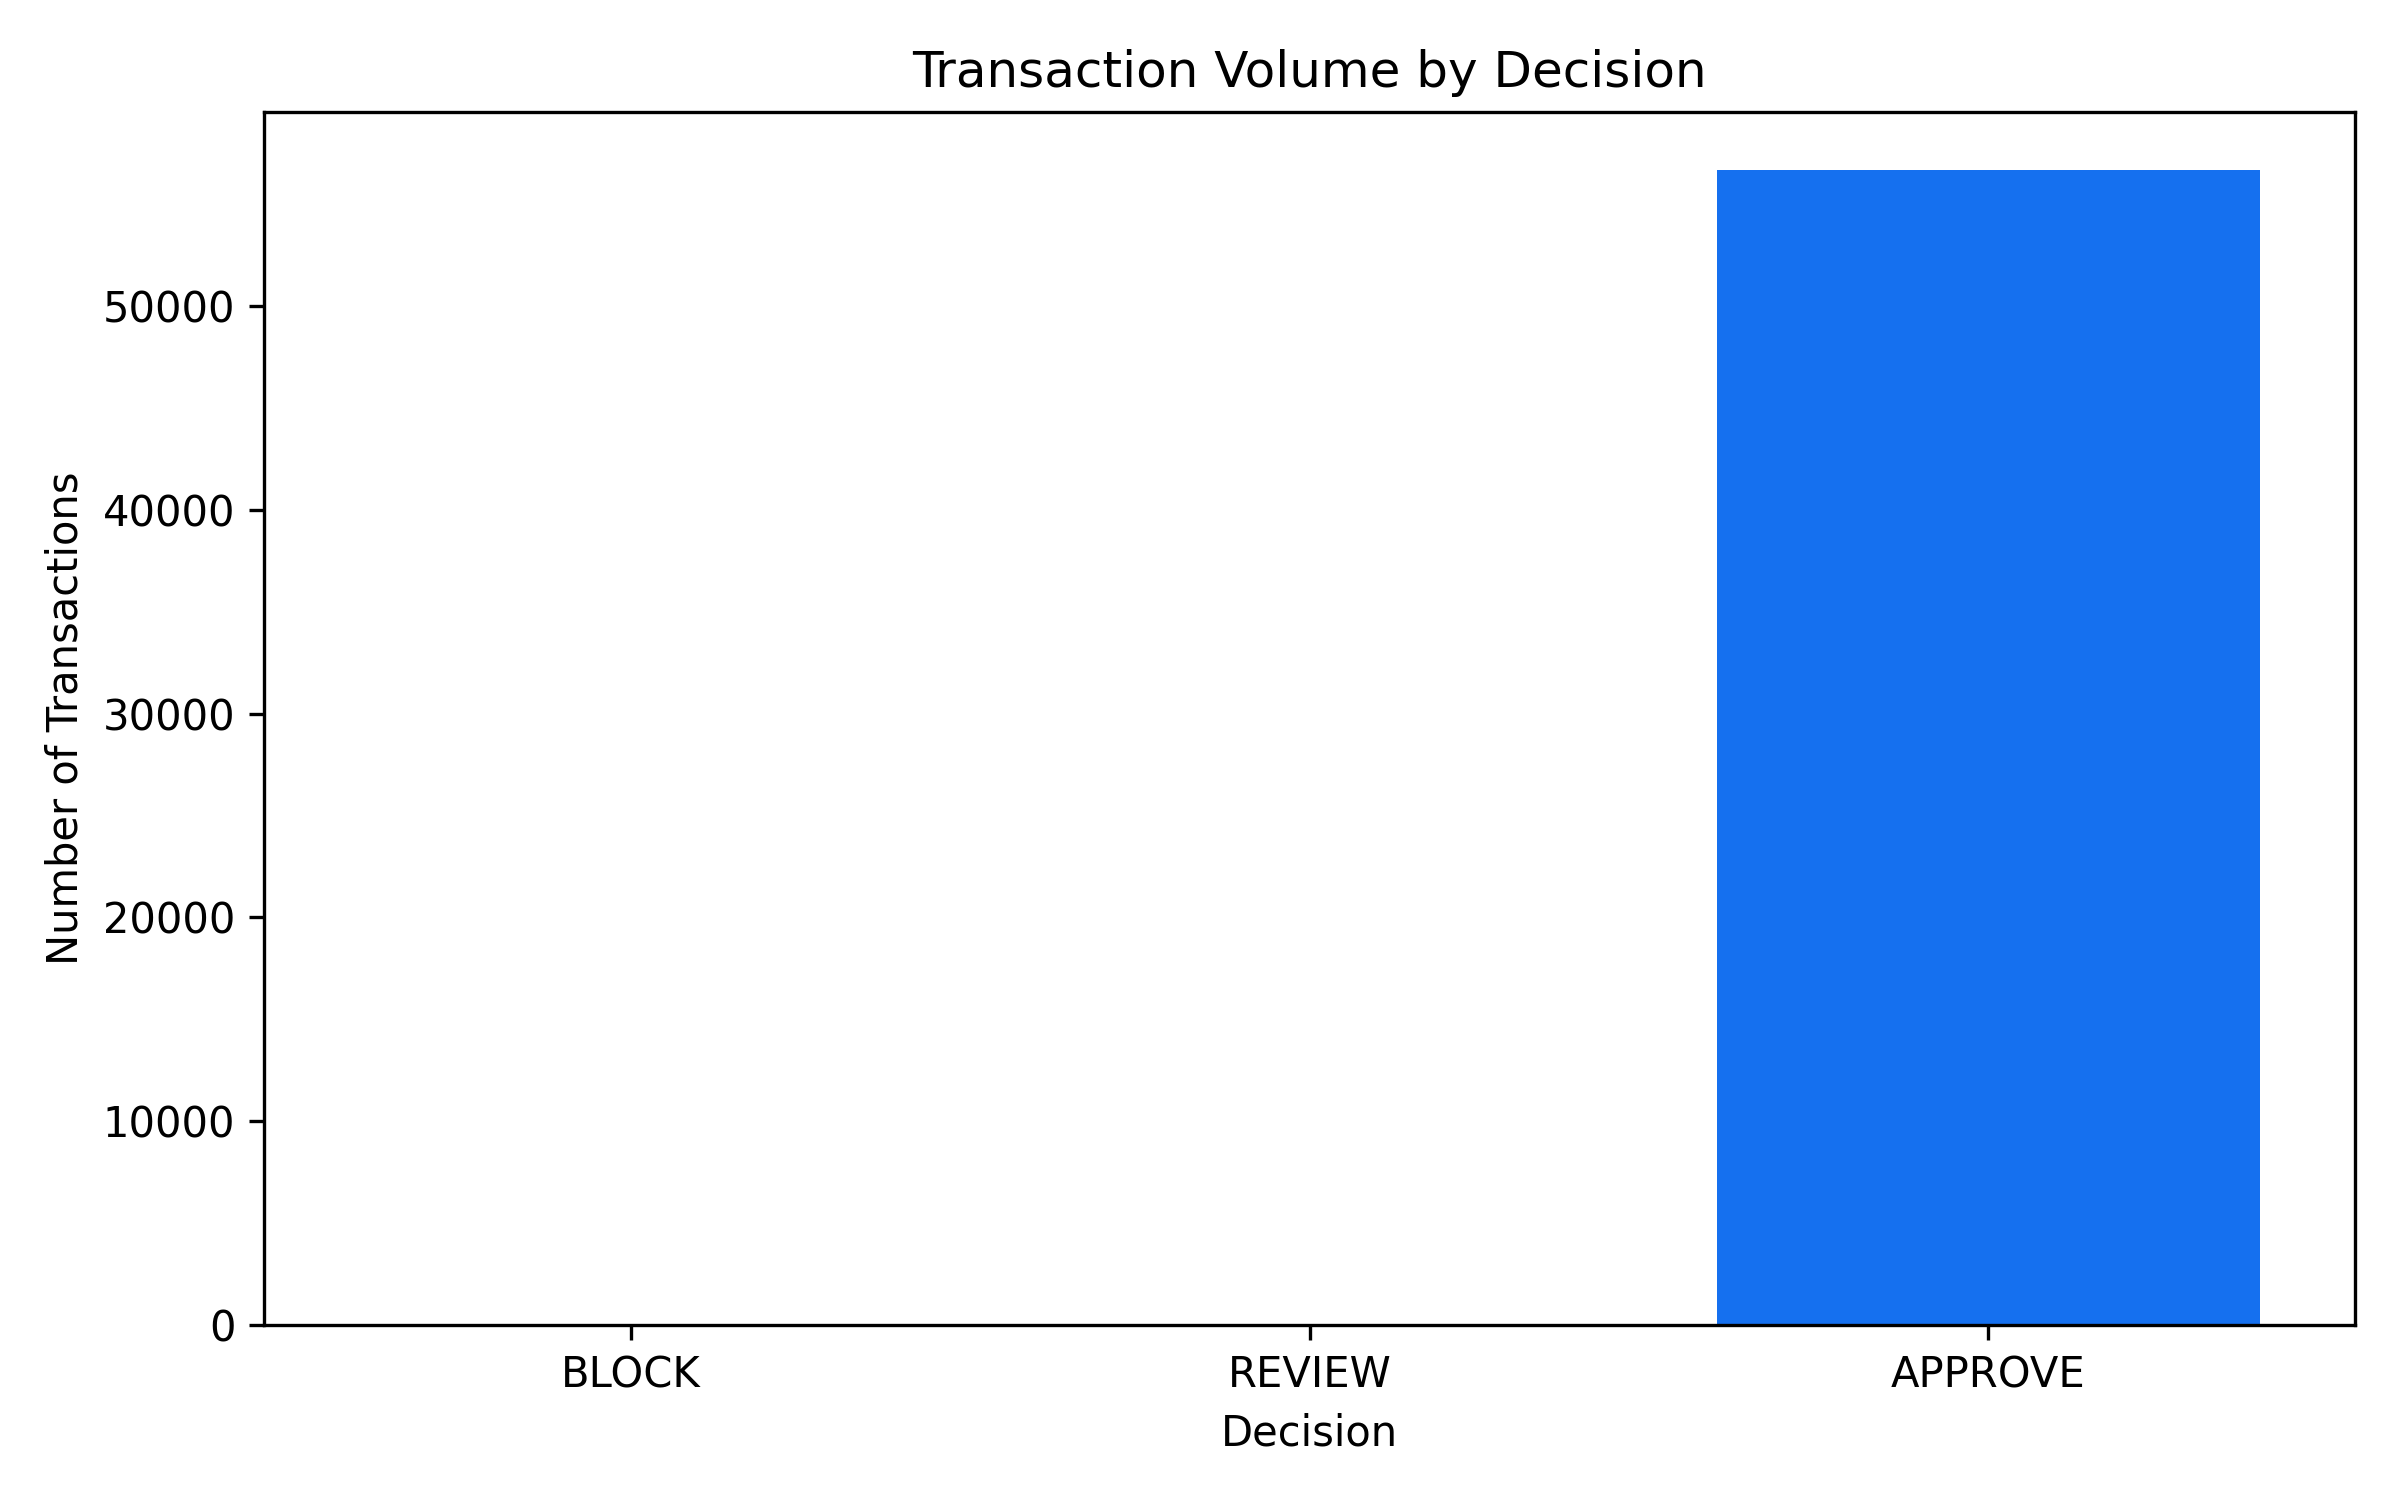

In [33]:
transaction_volume = business_impact_by_decision.set_index("decision").loc[DECISION_ORDER, "total_transactions"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(transaction_volume.index, transaction_volume.values, color=["#b42318", "#d97706", "#1570ef"])
ax.set_title("Transaction Volume by Decision")
ax.set_xlabel("Decision")
ax.set_ylabel("Number of Transactions")
fig.tight_layout()
fig.savefig(TRANSACTION_VOLUME_FIGURE, dpi=300)
plt.close(fig)

print(f"Saved figure to: {TRANSACTION_VOLUME_FIGURE}")
if Image is not None:
    display(Image(filename=str(TRANSACTION_VOLUME_FIGURE)))


### Transaction Volume Chart Interpretation

A good result usually shows the majority of transactions in `APPROVE`, with smaller `REVIEW` and `BLOCK` groups. In the current result, the chart should be read as the expected operational volume for each action: blocked transactions are high-confidence fraud risk, reviewed transactions become manual workload, and approved transactions represent normal processing.


## 14B. Actual Frauds by Decision

This chart shows where the true fraud cases landed after applying the decision policy. It matters because the policy should concentrate fraud in `BLOCK` and `REVIEW`, while keeping fraud in `APPROVE` as low as possible.


Saved figure to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/16_decision_logic/actual_frauds_by_decision.png


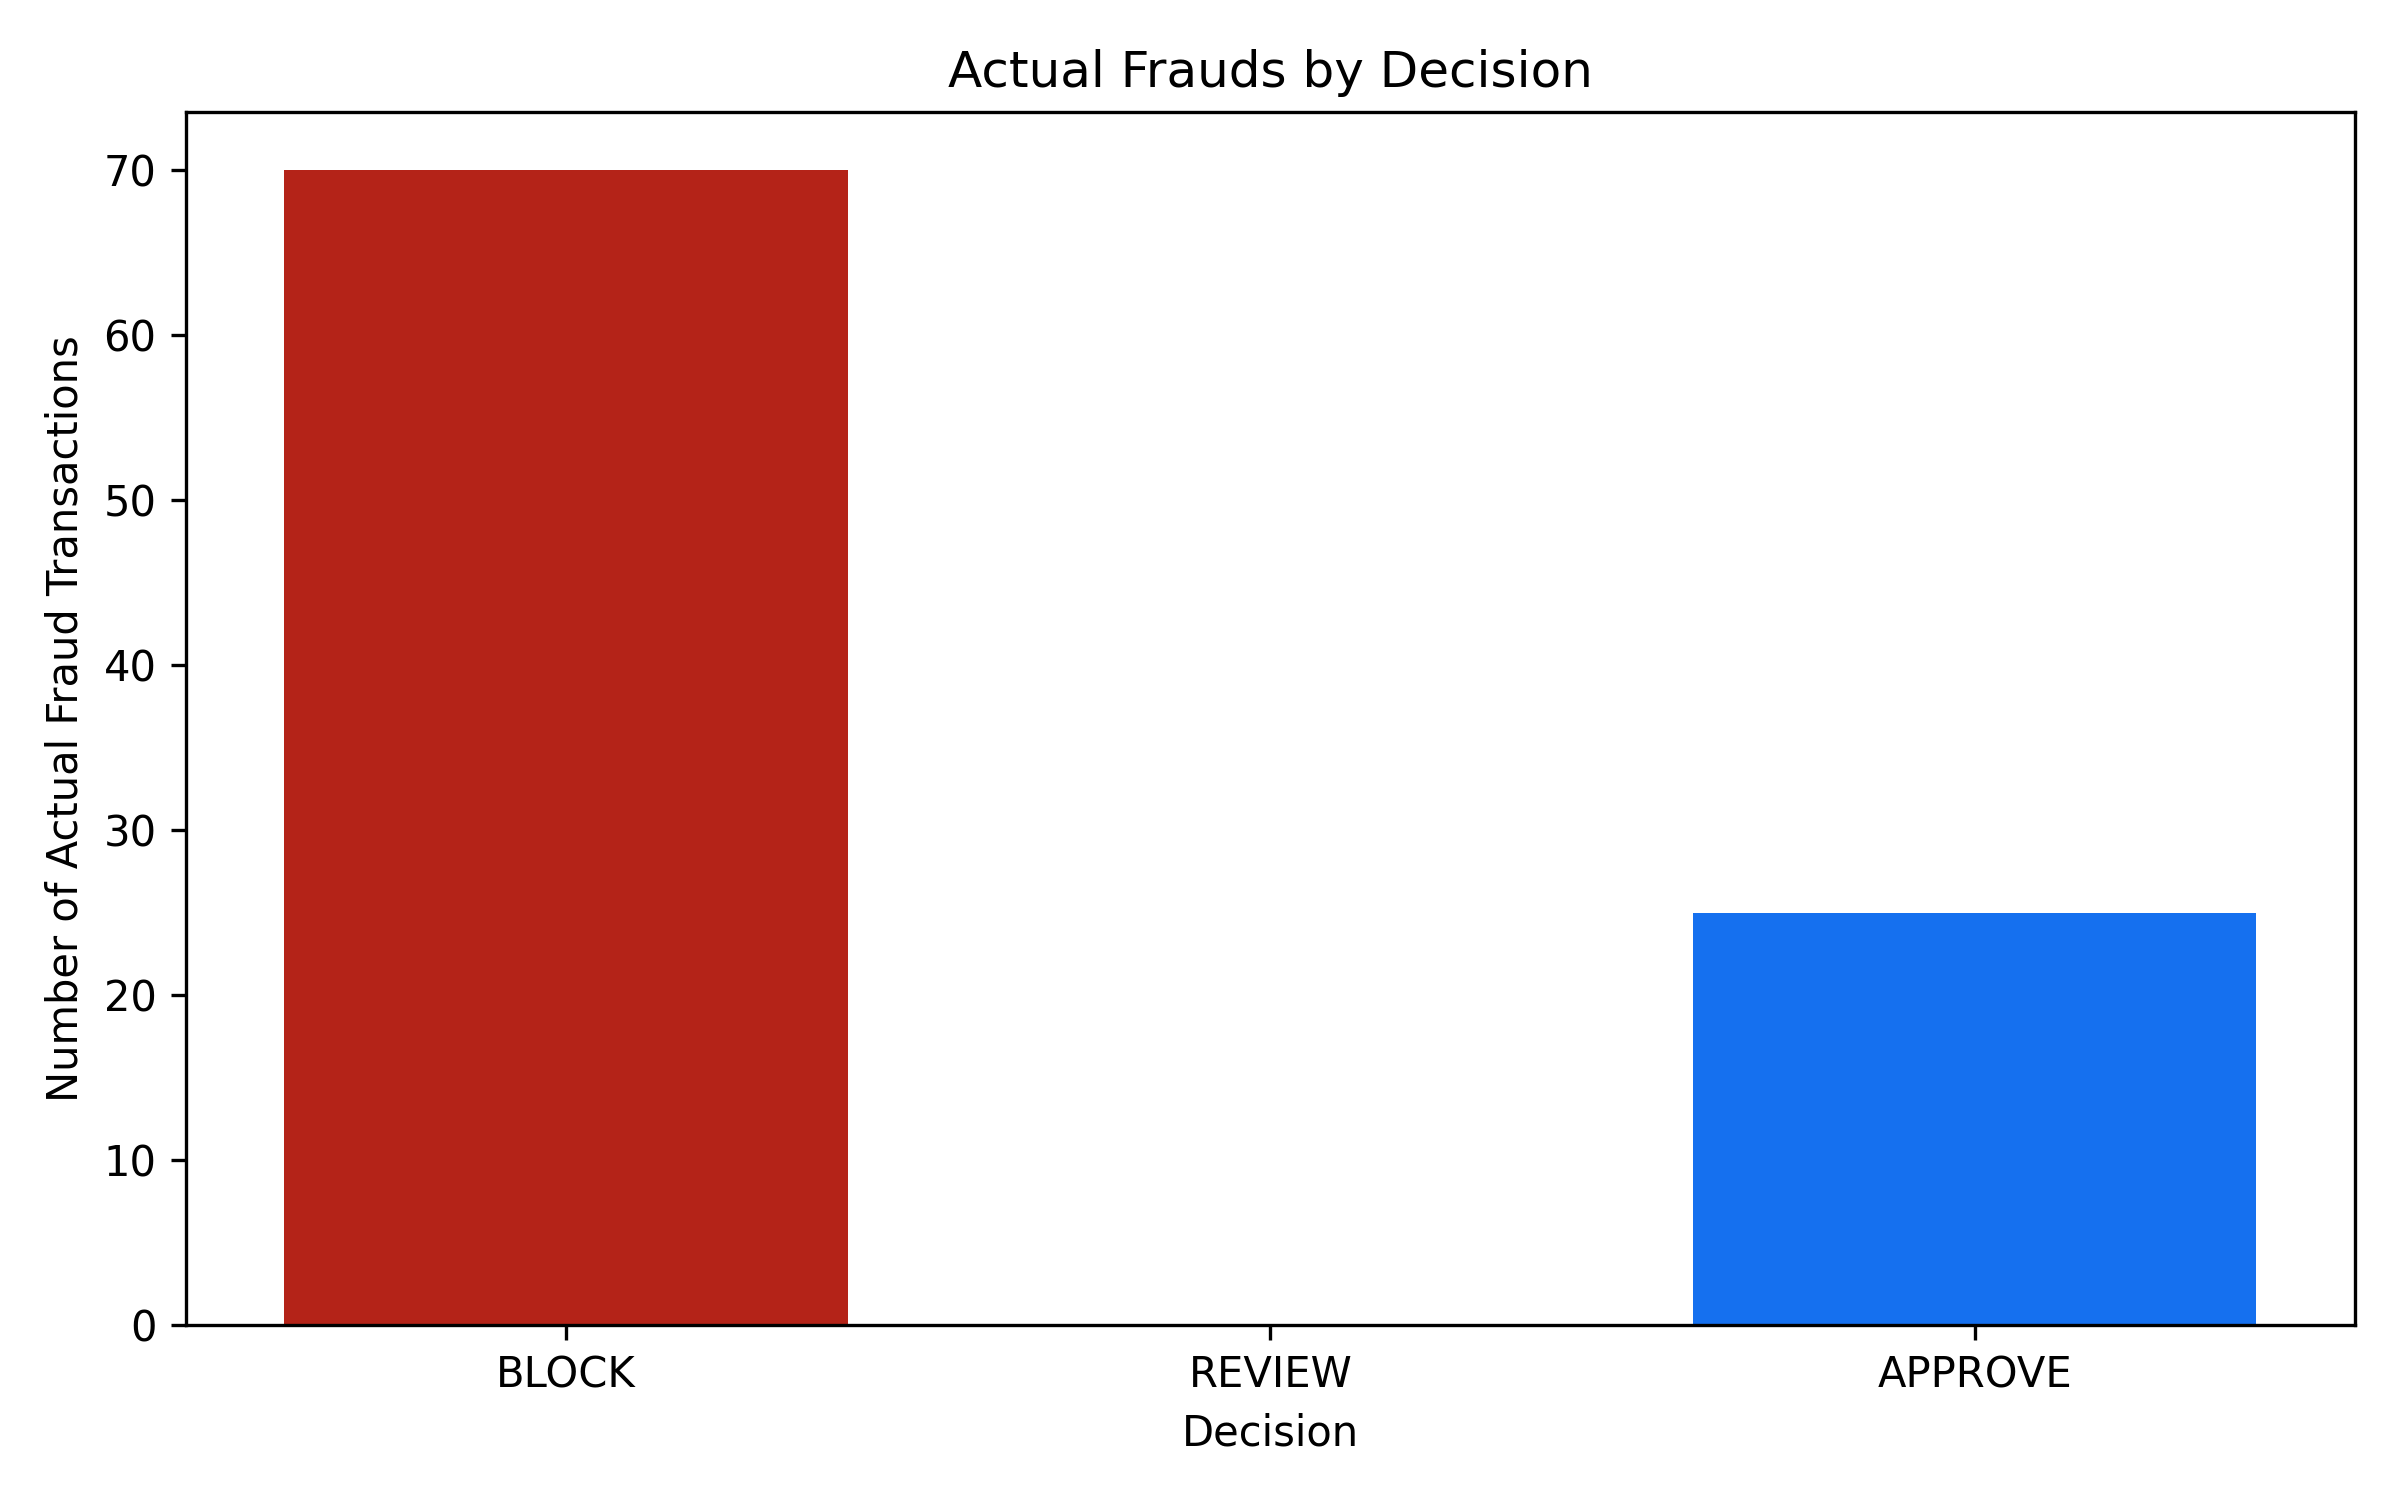

In [34]:
actual_frauds_by_decision = business_impact_by_decision.set_index("decision").loc[DECISION_ORDER, "actual_frauds"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(actual_frauds_by_decision.index, actual_frauds_by_decision.values, color=["#b42318", "#d97706", "#1570ef"])
ax.set_title("Actual Frauds by Decision")
ax.set_xlabel("Decision")
ax.set_ylabel("Number of Actual Fraud Transactions")
fig.tight_layout()
fig.savefig(ACTUAL_FRAUDS_FIGURE, dpi=300)
plt.close(fig)

print(f"Saved figure to: {ACTUAL_FRAUDS_FIGURE}")
if Image is not None:
    display(Image(filename=str(ACTUAL_FRAUDS_FIGURE)))


### Actual Frauds Chart Interpretation

A good result places most actual frauds in `BLOCK` or `REVIEW`. Fraud cases in `APPROVE` are missed frauds and should be monitored closely. The current chart shows how much fraud the final decision policy catches directly and how much remains as residual risk.


## 14C. Fraud Probability Distribution by Decision

This chart shows the distribution of Random Forest fraud probabilities inside each decision group. It matters because the decision groups should align with increasing model risk: approved transactions should have low probabilities, review transactions should sit in the middle band, and blocked transactions should have high probabilities.


In [ ]:
probability_data = [
    decision_results.loc[decision_results["decision"] == decision, "fraud_probability"].to_numpy()
    for decision in DECISION_ORDER
]

fig, ax = plt.subplots(figsize=(8, 5))
try:
    ax.boxplot(probability_data, tick_labels=DECISION_ORDER, showmeans=True)
except TypeError:
    ax.boxplot(probability_data, labels=DECISION_ORDER, showmeans=True)
ax.axhline(review_threshold, color="#d97706", linestyle="--", linewidth=1.5, label=f"Review threshold {review_threshold:.3f}")
ax.axhline(block_threshold, color="#b42318", linestyle="--", linewidth=1.5, label=f"Block threshold {block_threshold:.3f}")
ax.set_title("Fraud Probability Distribution by Decision")
ax.set_xlabel("Decision")
ax.set_ylabel("Fraud Probability")
ax.legend()
fig.tight_layout()
fig.savefig(PROBABILITY_DISTRIBUTION_FIGURE, dpi=300)
plt.close(fig)

print(f"Saved figure to: {PROBABILITY_DISTRIBUTION_FIGURE}")
if Image is not None:
    display(Image(filename=str(PROBABILITY_DISTRIBUTION_FIGURE)))


### Fraud Probability Distribution Interpretation

A good result has clear separation between decision groups, with `APPROVE` below the review threshold, `REVIEW` between thresholds, and `BLOCK` above the block threshold. This chart verifies that the business rules are being applied consistently to the model probabilities.


## 14D. Fraud vs Legitimate Counts by Decision

This chart compares actual fraud and legitimate counts inside each decision group. It matters because every decision group has a different business cost: fraud in `APPROVE` is missed fraud, legitimate transactions in `BLOCK` are false blocks, and legitimate transactions in `REVIEW` create manual workload.


Saved figure to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/16_decision_logic/fraud_vs_legitimate_by_decision.png


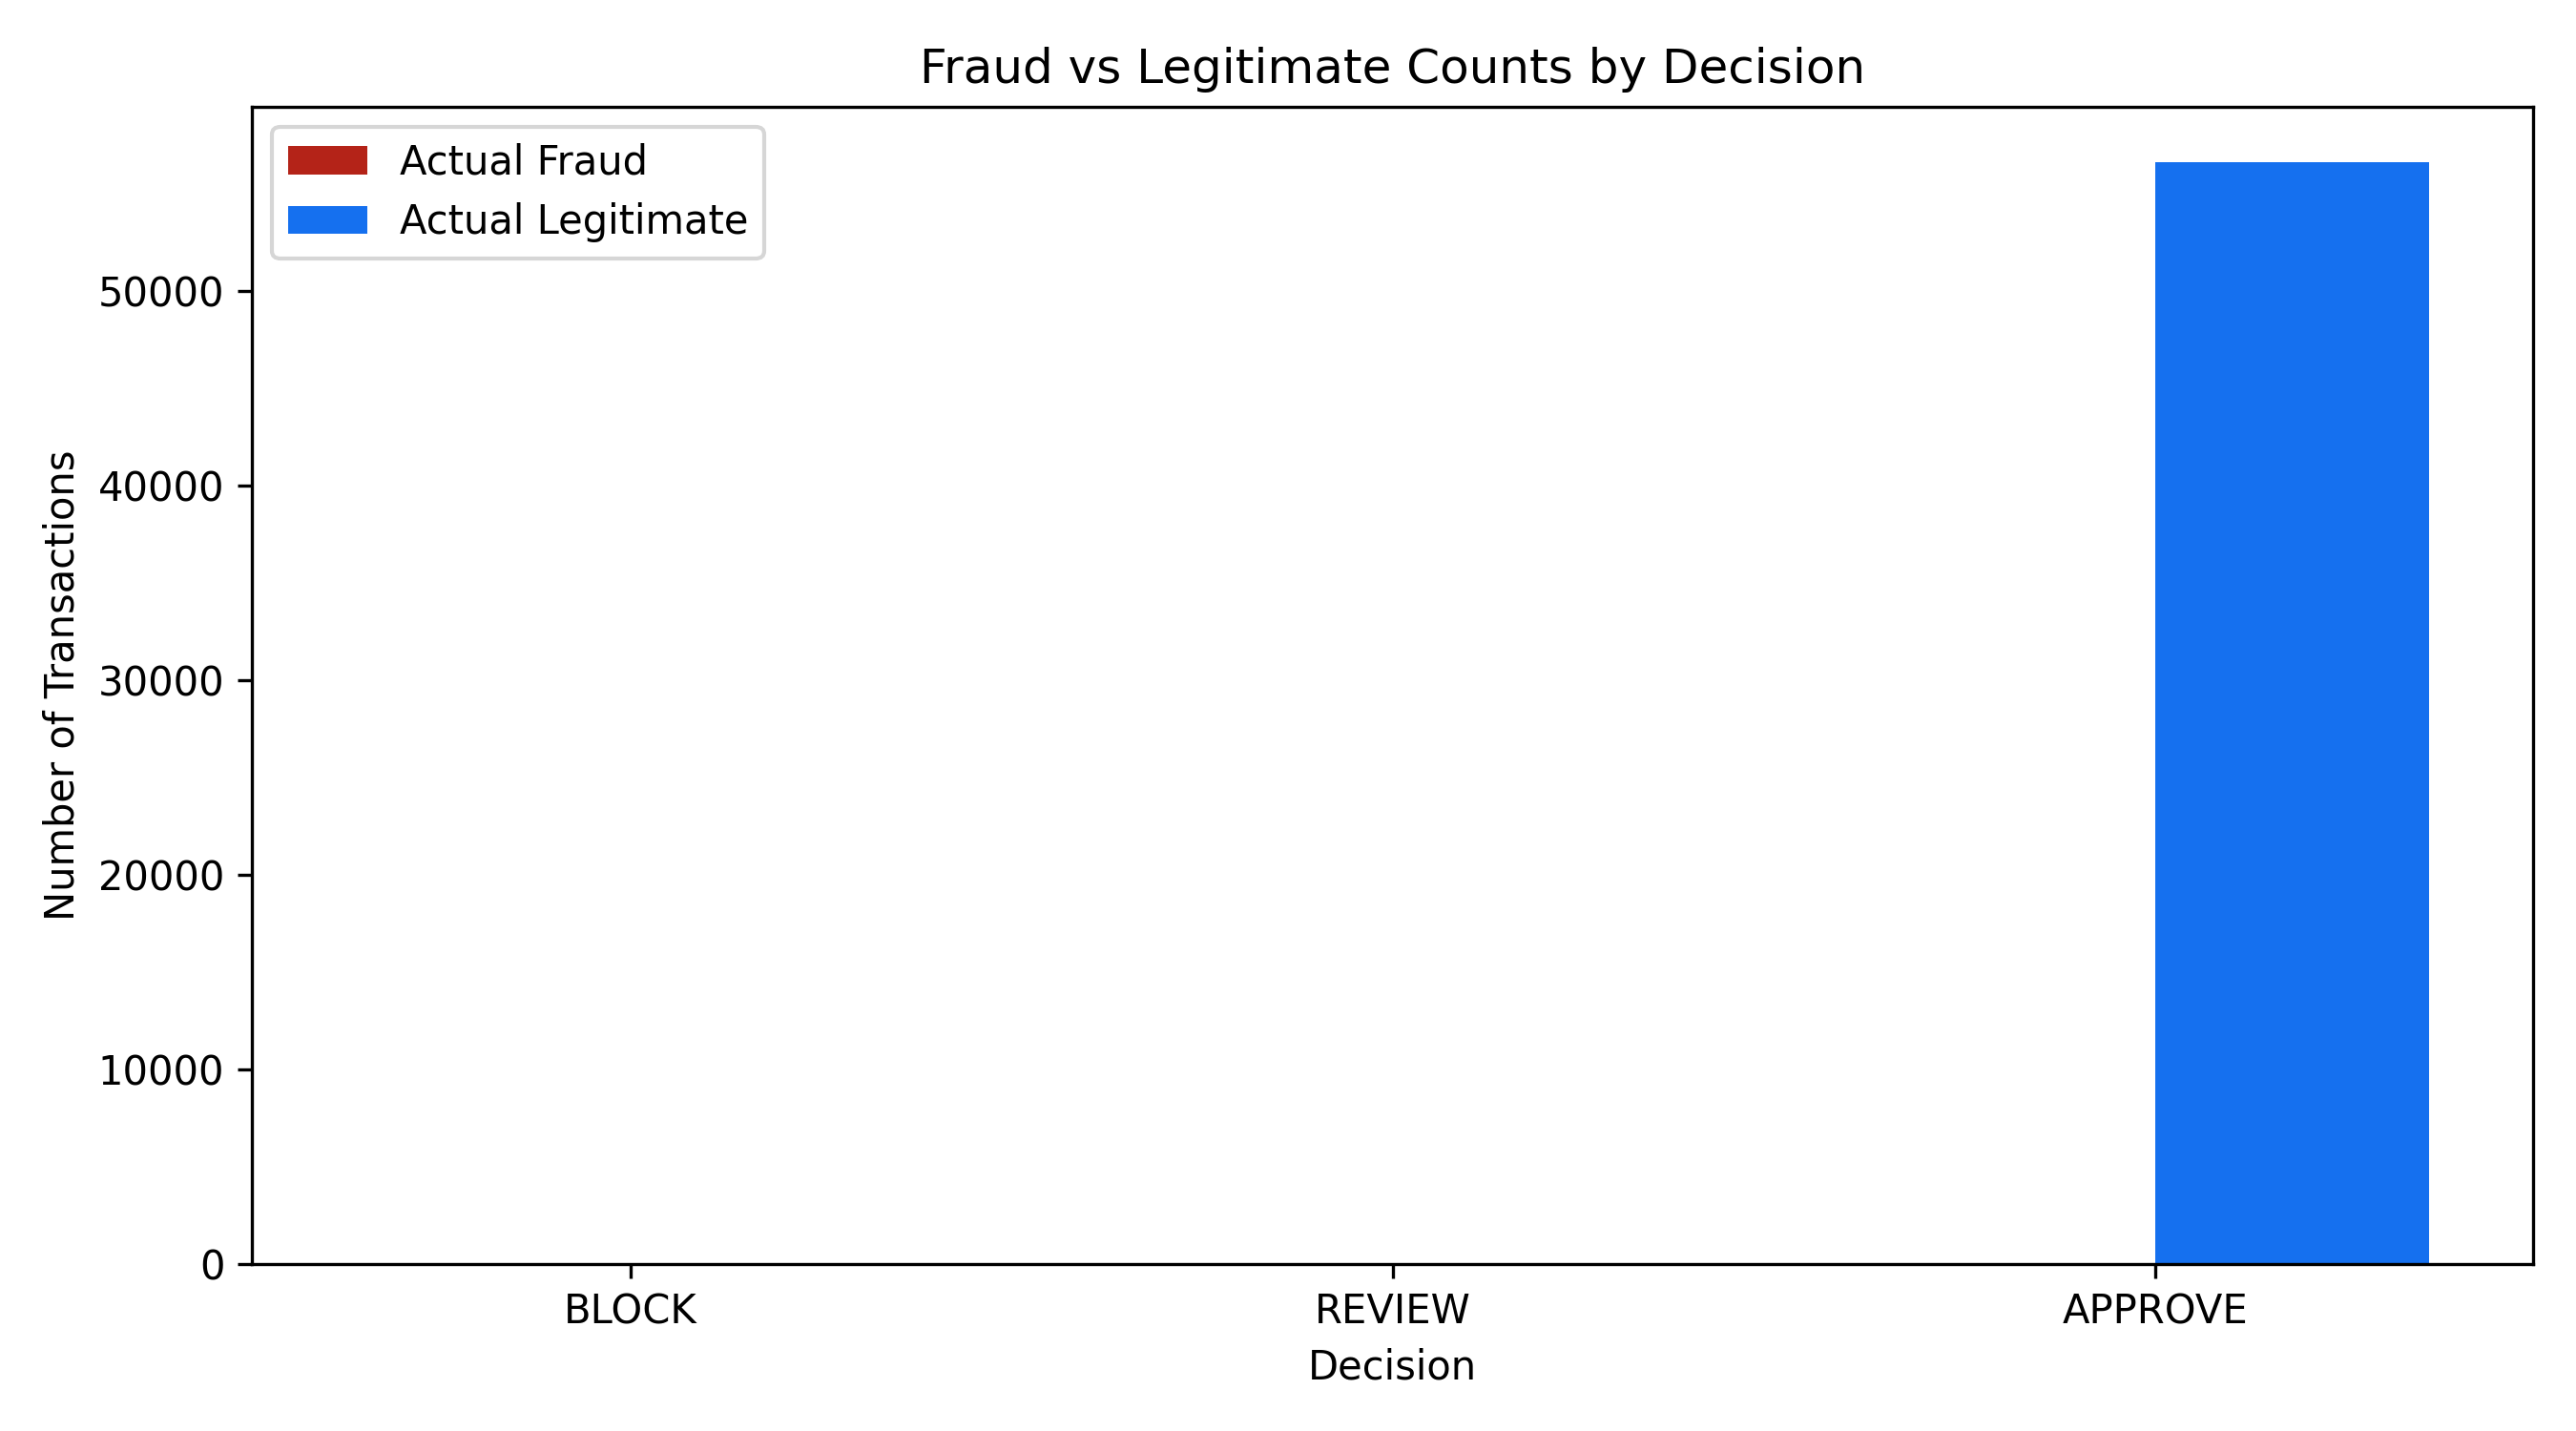

In [36]:
fraud_legitimate_counts = business_impact_by_decision.set_index("decision").loc[
    DECISION_ORDER,
    ["actual_frauds", "actual_legitimate"],
]

x_positions = np.arange(len(DECISION_ORDER))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_positions - bar_width / 2, fraud_legitimate_counts["actual_frauds"], width=bar_width, label="Actual Fraud", color="#b42318")
ax.bar(x_positions + bar_width / 2, fraud_legitimate_counts["actual_legitimate"], width=bar_width, label="Actual Legitimate", color="#1570ef")
ax.set_title("Fraud vs Legitimate Counts by Decision")
ax.set_xlabel("Decision")
ax.set_ylabel("Number of Transactions")
ax.set_xticks(x_positions)
ax.set_xticklabels(DECISION_ORDER)
ax.legend()
fig.tight_layout()
fig.savefig(FRAUD_VS_LEGITIMATE_FIGURE, dpi=300)
plt.close(fig)

print(f"Saved figure to: {FRAUD_VS_LEGITIMATE_FIGURE}")
if Image is not None:
    display(Image(filename=str(FRAUD_VS_LEGITIMATE_FIGURE)))


### Fraud vs Legitimate Chart Interpretation

A good result has high fraud concentration in `BLOCK`, manageable legitimate volume in `REVIEW`, and very few frauds in `APPROVE`. The current chart should be interpreted as the direct business trade-off between fraud prevention, manual-review workload, and customer friction.


## 15. Optional Policy Comparison: Operational block threshold vs block threshold candidate

If a stricter block threshold candidate exists, this section compares it against the default final policy. This comparison is for business discussion only. The default final policy still uses the `block_threshold` loaded from `selected_threshold.json`.


In [37]:
def apply_decision_policy(
    prediction_df: pd.DataFrame,
    probability_column: str,
    review_threshold: float,
    block_threshold: float,
    policy_name: str,
) -> pd.DataFrame:
    """Apply a review/block decision policy to a prediction DataFrame."""
    if probability_column not in prediction_df.columns:
        raise ValueError(f"Missing probability column: {probability_column}")

    output = prediction_df.copy()
    output["fraud_probability"] = output[probability_column].astype(float)
    output["policy_name"] = policy_name
    output["policy_review_threshold"] = review_threshold
    output["policy_block_threshold"] = block_threshold
    output["decision"] = output["fraud_probability"].apply(
        lambda probability: assign_fraud_decision(probability, review_threshold, block_threshold)
    )
    return output


def summarize_policy(policy_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize one applied decision policy by decision group."""
    policy_name = policy_df["policy_name"].iloc[0]
    rows = []
    for decision in DECISION_ORDER:
        subset = policy_df.loc[policy_df["decision"] == decision]
        actual_frauds = int(subset["y_true"].sum())
        total_transactions = int(len(subset))
        rows.append(
            {
                "policy_name": policy_name,
                "decision": decision,
                "review_threshold": float(policy_df["policy_review_threshold"].iloc[0]),
                "block_threshold": float(policy_df["policy_block_threshold"].iloc[0]),
                "total_transactions": total_transactions,
                "actual_frauds": actual_frauds,
                "actual_legitimate": total_transactions - actual_frauds,
                "false_blocks": int(((subset["decision"] == "BLOCK") & (subset["y_true"] == 0)).sum()),
                "false_reviews": int(((subset["decision"] == "REVIEW") & (subset["y_true"] == 0)).sum()),
                "frauds_missed": int(((subset["decision"] == "APPROVE") & (subset["y_true"] == 1)).sum()),
            }
        )
    return pd.DataFrame(rows)

if block_threshold_candidate is not None:
    policy_a = apply_decision_policy(
        predictions,
        "random_forest_probability",
        review_threshold,
        block_threshold,
        f"Policy A: operational block {block_threshold:.3f}",
    )
    policy_b = apply_decision_policy(
        predictions,
        "random_forest_probability",
        review_threshold,
        block_threshold_candidate,
        f"Policy B: candidate block {block_threshold_candidate:.3f}",
    )
    decision_policy_comparison = pd.concat(
        [summarize_policy(policy_a), summarize_policy(policy_b)],
        ignore_index=True,
    )
else:
    decision_policy_comparison = pd.DataFrame(
        columns=[
            "policy_name",
            "decision",
            "review_threshold",
            "block_threshold",
            "total_transactions",
            "actual_frauds",
            "actual_legitimate",
            "false_blocks",
            "false_reviews",
            "frauds_missed",
        ]
    )
    print("No block_threshold_candidate is available, so policy comparison table is empty.")

decision_policy_comparison.to_csv(POLICY_COMPARISON_FILE, index=False)

display(decision_policy_comparison)
print(f"Saved policy comparison table to: {POLICY_COMPARISON_FILE}")


,policy_name,decision,review_threshold,block_threshold,total_transactions,actual_frauds,actual_legitimate,false_blocks,false_reviews,frauds_missed
0,Policy A: operational block 0.500,BLOCK,0.350000,0.500000,73,70,3,3,0,0
1,Policy A: operational block 0.500,REVIEW,0.350000,0.500000,1,0,1,0,1,0
2,Policy A: operational block 0.500,APPROVE,0.350000,0.500000,56672,25,56647,0,0,25
3,Policy B: candidate block 0.821,BLOCK,0.350000,0.821000,60,59,1,1,0,0
4,Policy B: candidate block 0.821,REVIEW,0.350000,0.821000,14,11,3,0,3,0
5,Policy B: candidate block 0.821,APPROVE,0.350000,0.821000,56672,25,56647,0,0,25


Saved policy comparison table to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/16_decision_logic/decision_policy_comparison.csv


### Policy Comparison Interpretation

A lower block threshold blocks more transactions and may stop more fraud automatically, but it can also increase false blocks. A stricter block threshold may reduce false blocks but move more transactions into manual review or leave fewer frauds automatically blocked. This comparison supports business discussion only; the final default policy still uses the `block_threshold` saved in `selected_threshold.json`.


## 16. API-Ready Decision Response

The function below builds a JSON-like response that can be reused in a FastAPI `/predict` endpoint. It returns the transaction ID, fraud probability, risk level, decision, reason, and thresholds used for the decision.


In [ ]:
def build_decision_response(
    transaction_id: Any,
    fraud_probability: float,
    review_threshold: float,
    block_threshold: float,
    amount: float | None = None,
) -> dict:
    """Build an API-ready fraud decision response for one transaction using JSON-safe values."""
    decision = assign_fraud_decision(fraud_probability, review_threshold, block_threshold)
    risk_level = assign_risk_level(fraud_probability, review_threshold, block_threshold)
    reason = generate_decision_reason(fraud_probability, decision, review_threshold, block_threshold)

    if hasattr(transaction_id, "item"):
        transaction_id = transaction_id.item()

    response = {
        "transaction_id": transaction_id,
        "fraud_probability": round(float(fraud_probability), 6),
        "risk_level": risk_level,
        "decision": decision,
        "reason": reason,
        "thresholds": {
            "review_threshold": float(review_threshold),
            "block_threshold": float(block_threshold),
        },
    }
    if amount is not None:
        response["amount"] = round(float(amount), 2)
    return response

example_responses = []
for decision in DECISION_ORDER:
    matching_rows = decision_results.loc[decision_results["decision"] == decision]
    if matching_rows.empty:
        print(f"No holdout transaction fell into the {decision} band, so no {decision} example is shown.")
        continue
    example_row = matching_rows.sort_values("fraud_probability", ascending=False).iloc[0]
    example_responses.append(
        build_decision_response(
            example_row["transaction_id"],
            example_row["fraud_probability"],
            review_threshold,
            block_threshold,
        )
    )

print(json.dumps(example_responses, indent=2))


### API Response Interpretation

The examples show the exact response structure expected from the future fraud decision endpoint. A `BLOCK` example should have probability at or above the block threshold, a `REVIEW` example should fall between thresholds if one exists, and an `APPROVE` example should be below the review threshold.


## 17. Save Final Decision Policy Artifact

This artifact is the compact policy file that downstream FastAPI code can load. It records the selected model, thresholds, decision rules, risk-level rules, and source files used to create the policy.


In [ ]:
decision_policy_artifact = {
    "model_name": model_name,
    "review_threshold": review_threshold,
    "block_threshold": block_threshold,
    "block_threshold_candidate": block_threshold_candidate,
    "decision_policy": {
        "APPROVE": "fraud_probability < review_threshold",
        "REVIEW": "review_threshold <= fraud_probability < block_threshold",
        "BLOCK": "fraud_probability >= block_threshold",
    },
    "risk_levels": {
        "Very High Risk": "fraud_probability >= block_threshold",
        "High Risk": "max(block_threshold - 0.10, review_threshold) <= fraud_probability < block_threshold",
        "Medium Risk": "review_threshold <= fraud_probability < max(block_threshold - 0.10, review_threshold)",
        "Low-Medium Risk": "0.10 <= fraud_probability < review_threshold",
        "Low Risk": "fraud_probability < 0.10",
    },
    "source_threshold_artifact": str(THRESHOLD_ARTIFACT_FILE.relative_to(PROJECT_ROOT)),
    "source_prediction_file": str(PREDICTION_FILE.relative_to(PROJECT_ROOT)),
    "intended_use": "FastAPI fraud decision response",
}

DECISION_POLICY_FILE.write_text(json.dumps(decision_policy_artifact, indent=2), encoding="utf-8")

print(f"Saved decision policy artifact to: {DECISION_POLICY_FILE}")
print(json.dumps(decision_policy_artifact, indent=2))


### Decision Policy Artifact Interpretation

The saved `decision_policy.json` is intentionally small and API-oriented. It separates the review and block thresholds, preserves the optional block candidate, and documents the exact decision and risk-level rules that application code should apply.


## 18. Save Final Decision Summary

The final summary table collects the most important operational metrics in one place. This is useful for a project README, portfolio summary, or FastAPI integration checklist.


In [40]:
transactions_blocked = int((decision_results["decision"] == "BLOCK").sum())
transactions_reviewed = int((decision_results["decision"] == "REVIEW").sum())
transactions_approved = int((decision_results["decision"] == "APPROVE").sum())

final_decision_summary = pd.DataFrame(
    [
        {"metric": "Selected model", "value": model_name},
        {"metric": "Review threshold", "value": review_threshold},
        {"metric": "Block threshold", "value": block_threshold},
        {"metric": "Block threshold candidate", "value": block_threshold_candidate},
        {"metric": "Total holdout transactions", "value": len(decision_results)},
        {"metric": "Total actual frauds", "value": total_frauds},
        {"metric": "Transactions blocked", "value": transactions_blocked},
        {"metric": "Transactions reviewed", "value": transactions_reviewed},
        {"metric": "Transactions approved", "value": transactions_approved},
        {"metric": "Frauds blocked", "value": frauds_blocked},
        {"metric": "Frauds reviewed", "value": frauds_sent_to_review},
        {"metric": "Frauds missed", "value": frauds_missed},
        {"metric": "False blocks", "value": false_block_count},
        {"metric": "False reviews", "value": false_review_count},
        {"metric": "Fraud capture rate", "value": fraud_capture_rate},
    ]
)

final_decision_summary.to_csv(FINAL_DECISION_SUMMARY_FILE, index=False)

display(final_decision_summary)
print(f"Saved final decision summary to: {FINAL_DECISION_SUMMARY_FILE}")


,metric,value
0,Selected model,Random Forest
1,Review threshold,0.350000
2,Block threshold,0.500000
3,Block threshold candidate,0.821000
4,Total holdout transactions,56746
5,Total actual frauds,95
6,Transactions blocked,73
7,Transactions reviewed,1
8,Transactions approved,56672
9,Frauds blocked,70


Saved final decision summary to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/16_decision_logic/final_decision_summary.csv


### Final Decision Summary Interpretation

This summary confirms the final operational policy and its holdout/test impact. It shows how many transactions would be blocked, reviewed, or approved, plus the fraud capture rate and key business-error counts.


## 19. Final Conclusion

This notebook converted the Random Forest fraud probability into business decision logic without retraining models, retuning thresholds, or reselecting the best model.

The final policy is:

- `APPROVE` below the review threshold
- `REVIEW` between the review and block thresholds
- `BLOCK` at or above the block threshold

The notebook produced transaction-level decision results, business-impact tables, fraud-capture summaries, error-analysis tables, policy comparison outputs, and decision figures. It also saved `artifacts/decision_policy.json` for downstream application use.

The fraud decision logic is now ready for FastAPI `/predict` integration, where the API can return fraud probability, risk level, decision, reason, and the thresholds used for that decision.
